# Mission

### Task 1: Data Cleaning and Preprocessing

**objective**
- Clean dataset
- Make data consistent and ready for analysis.

### Task 2: Exploratory Data Analysis (EDA)
- The aim here is to explore the cleaned dataset to uncover patterns, identify trends, and formulate initial hypotheses.

### Task 3: Basic Data Visualization
- This task focuses specifically on the ability to create clear and informative plots to communicate findings effectively.

In [85]:
import pandas as pd

# loading iris dataset
df = pd.read_csv("datasets/iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [87]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [88]:
# checking for missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [89]:
# checking for duplicate rows
df.duplicated().sum()
print("No duplicate rows found" if df.duplicated().sum() == 0 else "Duplicate rows found")

Duplicate rows found


In [90]:
# showing the duplicate rows
print(df[df.duplicated()])

     sepal_length  sepal_width  petal_length  petal_width    species
34            4.9          3.1           1.5          0.1     setosa
37            4.9          3.1           1.5          0.1     setosa
142           5.8          2.7           5.1          1.9  virginica


In [91]:
# dropping row 
df = df.drop_duplicates()

# checking again for duplicate rows
df.duplicated().sum()
print("No duplicate rows found" if df.duplicated().sum() == 0 else "Duplicate rows found")

No duplicate rows found


In [92]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [93]:
# saving the cleaned dataset
df.to_csv("../Prepared_Datasets/iris_cleaned.csv", index=False)
df = pd.read_csv("../Prepared_Datasets/iris_cleaned.csv")

In [94]:
# Reading cleaned dataset
df = pd.read_csv("../Prepared_Datasets/iris_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [95]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


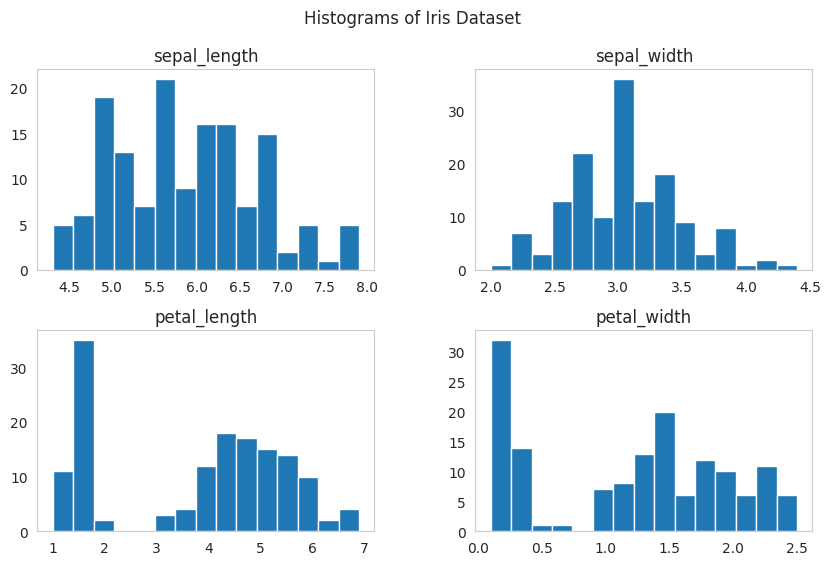

In [96]:
# Histograms
import matplotlib.pyplot as plt
df.hist(bins=15, figsize=(10, 6), grid=False)
plt.suptitle("Histograms of Iris Dataset")
plt.show()

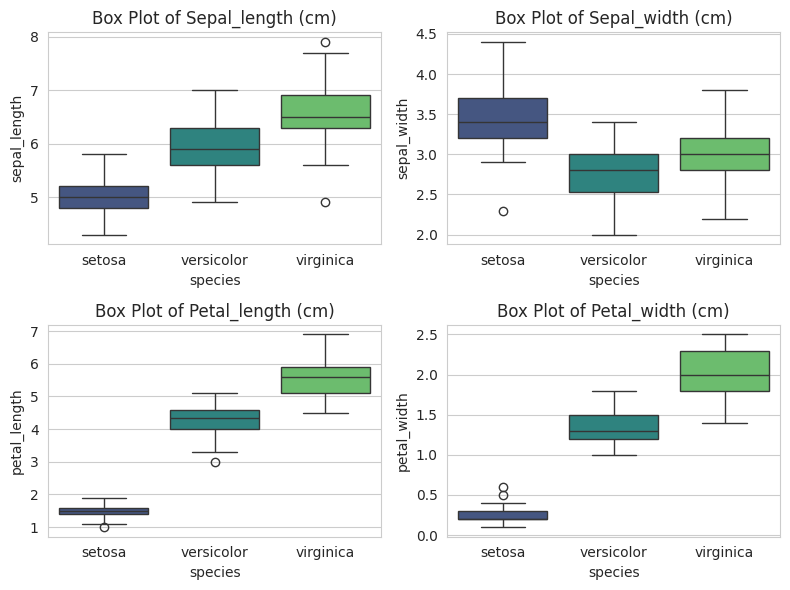

In [97]:
# Box plots for each size feature
import seaborn as sns

size_features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
plt.figure(figsize=(8,6))
sns.set_style("whitegrid")
for i, feature in enumerate(size_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=feature, x='species', hue='species', data=df, palette='viridis')
    plt.title(f'Box Plot of {feature.capitalize()} (cm)')
plt.tight_layout()

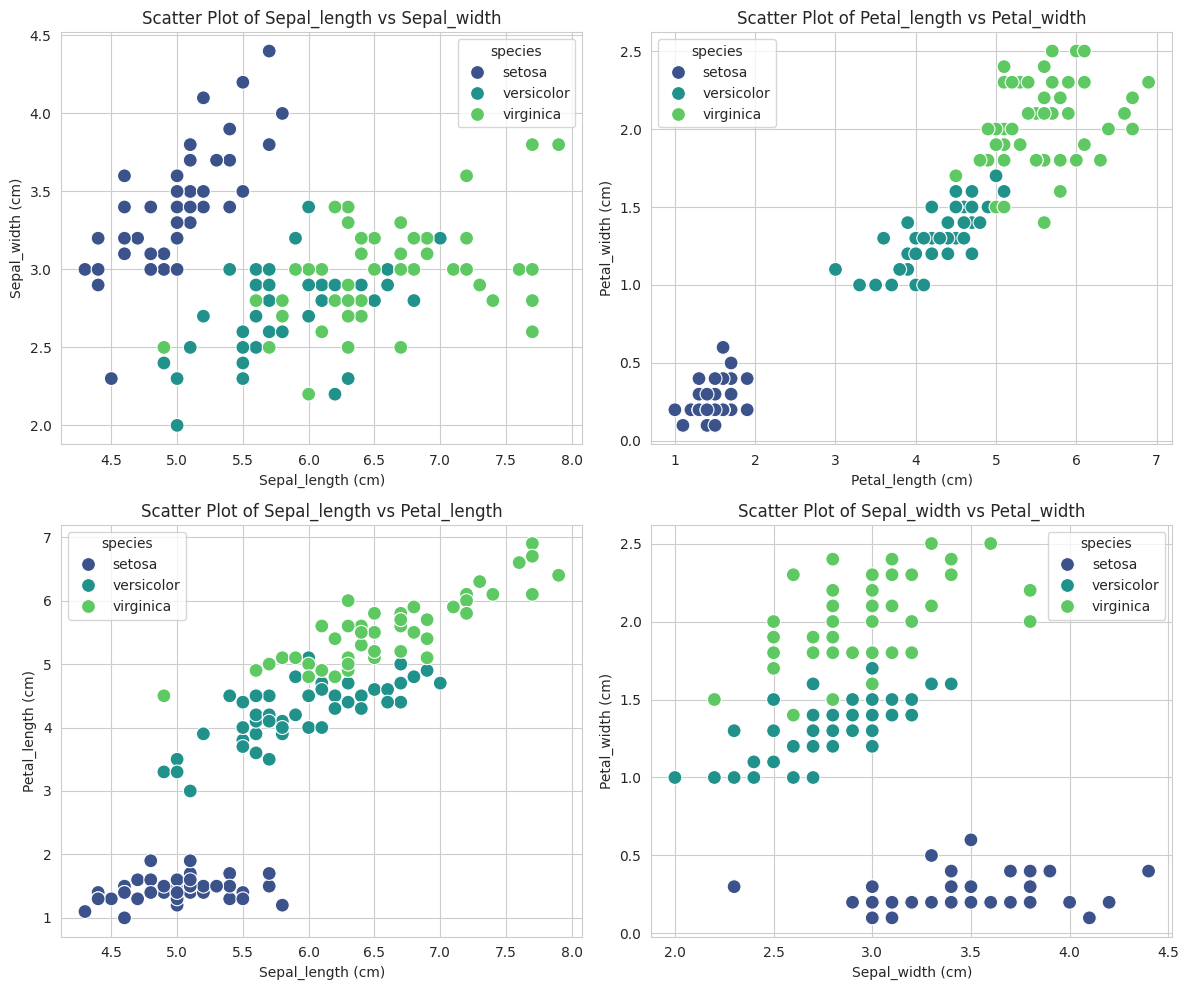

In [98]:
# Scatter plots for feature pairs
plt.figure(figsize=(12, 10))

feature_pairs = [('sepal_length', 'sepal_width'), ('petal_length', 'petal_width'),
                 ('sepal_length', 'petal_length'), ('sepal_width', 'petal_width')]

for i, (x_feat, y_feat) in enumerate(feature_pairs, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=x_feat, y=y_feat, hue='species', palette='viridis', s=100)
    plt.title(f'Scatter Plot of {x_feat.capitalize()} vs {y_feat.capitalize()}')
    plt.xlabel(f'{x_feat.capitalize()} (cm)')
    plt.ylabel(f'{y_feat.capitalize()} (cm)')
plt.tight_layout()
plt.show()  

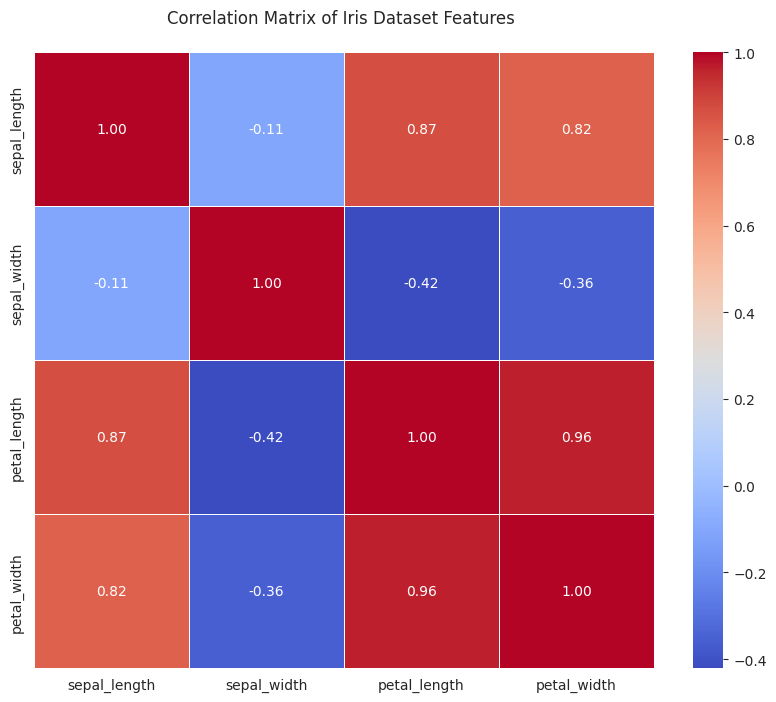

In [99]:
# Finding out the correlation between features
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Iris Dataset Features \n")
plt.show()  

**Note:** The color intensity and hue indicate the strength and direction of the correlation. Darker reds signify strong positive correlations, darker blues signify strong negative correlations, and lighter colors indicate weaker or no correlation.

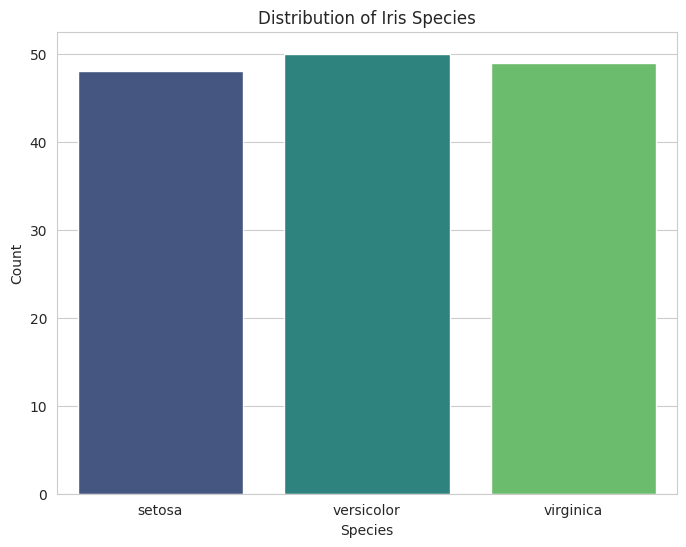

In [100]:
# Bar plot for species distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='species', hue='species', palette='viridis', legend=False)
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

## Analysis Summary: Iris Dataset Findings

### Task 1: Data Cleaning and Preprocessing - Key Findings

**Data Quality Assessment:**

- Dataset Size: 150 observations initially, reduced to 147 after cleaning
- Missing Values: None found, Dataset was complete
- Data Types: All appropriate 4 numerical features (float64) and 1 categorical (object)
- *Duplicate Records*: 3 duplicates identified and removed
  - 2 duplicates in Setosa species (rows 34 & 37)
  - 1 duplicate in Virginica species (row 142)

**Cleaning Actions Taken:**

1. Removed duplicate entries using `drop_duplicates()`
2. Saved cleaned dataset to `Prepared_Datasets/iris_cleaned.csv`
3. Verified data integrity post-cleaning

### Task 2: Exploratory Data Analysis - Discovered Patterns

**Dataset Structure:**

- Features: 4 measurements (sepal length, sepal width, petal length, petal width)
- Target: 3 species classes (Setosa, Versicolor, Virginica)
- Balance: Nearly equal distribution across species with 49 samples each

**Patterns found:**

- Sepal Length: Virginica has the largest sepals, Setosa the smallest
- Sepal Width: Setosa has the widest sepals, Virginica the narrowest
- Petal Length: Strong species differentiation - Virginica > Versicolor > Setosa
- Petal Width: Most distinctive feature for species classification

**Key Correlations Discovered:**
- Strong Positive: Petal length ↔ Petal width (0.96)
- Moderate Positive: Sepal length ↔ Petal length (0.87)
- Moderate Positive: Sepal length ↔ Petal width (0.82)
- Weak Negative: Sepal width ↔ Petal length (-0.42)

### Task 3: Data Visual Insights

**Distribution Patterns:**

1. Histograms: Revealed normal distributions for most features
2. Box Plots: Showed clear species separation, especially in petal measurements
3. Scatter Plots: Demonstrated distinct clusters for each species
4. Correlation Heatmap: Visualized feature relationships with color intensity

**Species Differentiation:**

- Setosa: Most distinct species with smallest petals and largest sepal width
- Versicolor: Intermediate characteristics between other species
- Virginica: Largest overall measurements, especially in petal dimensions


## My Research Findings

*1. Species Classification Potential*
- Petal measurements** are the most reliable for species identification
- Setosa can be easily distinguished from other species
- Versicolor vs Virginica requires more sophisticated analysis

*2. Feature Importance Ranking*
1. Petal Width- Highest discriminative power
2. Petal Length- Strong species separation
3. Sepal Length- Moderate discriminative value
4. Sepal Width-Least discriminative (some overlap)

**Final Data Quality:**
- High-quality dataset with minimal cleaning required
- No missing values or data type issues
- Only minor duplicate removal needed
